# Практические работы 1.1 и 1.2

**Выполнил студент группы 955-М:** Хайбулин Никита Сергеевич

## Практика 1.1. Iris

Подготовка данных.

In [1]:
import numpy as np
np.random.seed(42)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_theme(style='whitegrid')

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print('Размер датасета:', df.shape)
display(df.head())
print('\nИнформация о данных:')
df.info()
display(df.describe().round(3))

Размер датасета: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   target             150 non-null    int64   
 5   species            150 non-null    category
dtypes: category(1), float64(4), int64(1)
memory usage: 6.3 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199,1.000
std,0.828,0.436,1.765,0.762,0.819
min,4.300,2.000,1.000,0.100,0.000
25%,5.100,2.800,1.600,0.300,0.000
50%,5.800,3.000,4.350,1.300,1.000
75%,6.400,3.300,5.100,1.800,2.000
max,7.900,4.400,6.900,2.500,2.000


### Задание 1. Анализ выбросов

Построить boxplot для каждого признака с разбивкой по видам. Определить, есть ли выбросы у *Iris virginica* по признаку `sepal width (cm)`, и какой процент наблюдений выходит за границы усов.

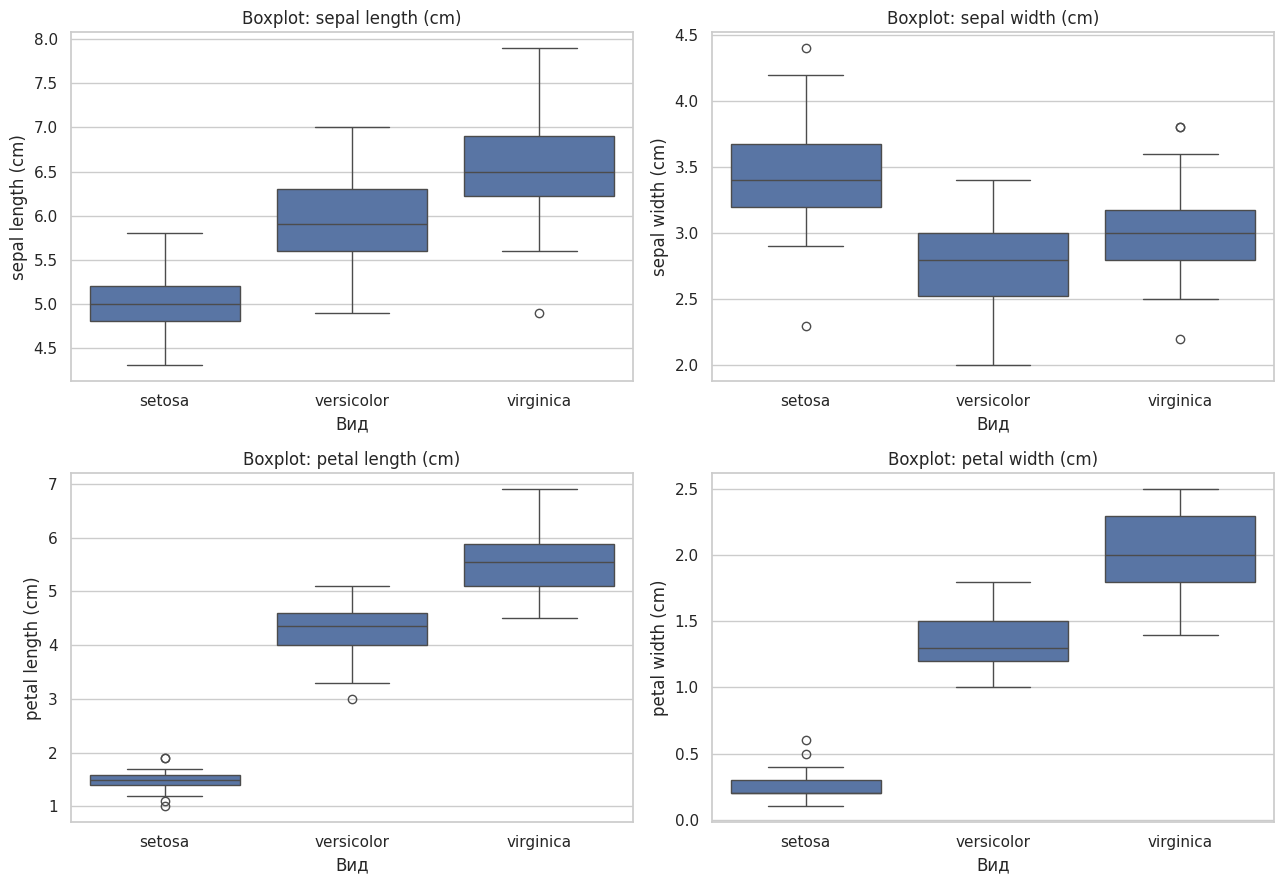

Q1 = 2.800
Q3 = 3.175
IQR = 0.375
Нижняя граница уса = 2.237
Верхняя граница уса = 3.738
Количество выбросов у Iris virginica по sepal width: 3 из 50
Процент выбросов: 6.00%


,sepal width (cm),species
117,3.8,virginica
119,2.2,virginica
131,3.8,virginica


In [2]:
features = iris.feature_names

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(data=df, x='species', y=feature, ax=ax)
    ax.set_title(f'Boxplot: {feature}')
    ax.set_xlabel('Вид')
    ax.set_ylabel(feature)
plt.tight_layout()
plt.show()

virginica = df[df['species'] == 'virginica']
q1 = virginica['sepal width (cm)'].quantile(0.25)
q3 = virginica['sepal width (cm)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = virginica[(virginica['sepal width (cm)'] < lower_bound) | (virginica['sepal width (cm)'] > upper_bound)]
outlier_percent = len(outliers) / len(virginica) * 100

print(f'Q1 = {q1:.3f}')
print(f'Q3 = {q3:.3f}')
print(f'IQR = {iqr:.3f}')
print(f'Нижняя граница уса = {lower_bound:.3f}')
print(f'Верхняя граница уса = {upper_bound:.3f}')
print(f'Количество выбросов у Iris virginica по sepal width: {len(outliers)} из {len(virginica)}')
print(f'Процент выбросов: {outlier_percent:.2f}%')
display(outliers[['sepal width (cm)', 'species']])

### Задание 2. Сравнение дисперсий

Рассчитать коэффициент вариации для каждого признака и определить наиболее изменчивый признак.

In [3]:
cv = (df[features].std() / df[features].mean() * 100).sort_values(ascending=False)
cv_table = cv.reset_index()
cv_table.columns = ['Признак', 'Коэффициент вариации, %']
display(cv_table.round(2))

most_variable = cv.idxmax()
print(f'Наиболее изменчивый признак относительно среднего: {most_variable}')
print(f'Коэффициент вариации: {cv.max():.2f}%')

,Признак,"Коэффициент вариации, %"
0,petal width (cm),63.56
1,petal length (cm),46.97
2,sepal width (cm),14.26
3,sepal length (cm),14.17


Наиболее изменчивый признак относительно среднего: petal width (cm)
Коэффициент вариации: 63.56%


**Вывод:** самый высокий коэффициент вариации имеет `petal width (cm)`. Это важно для нормализации: признаки с разными масштабами и относительной изменчивостью могут непропорционально влиять на алгоритмы, основанные на расстояниях или градиентной оптимизации.

### Задание 3. Создание нового признака

Создать признак `petal_ratio = petal length / petal width`, построить распределение по видам и оценить, улучшает ли он разделение классов.

,petal length (cm),petal width (cm),petal_ratio,species
0,1.4,0.2,7.0,setosa
1,1.4,0.2,7.0,setosa
2,1.3,0.2,6.5,setosa
3,1.5,0.2,7.5,setosa
4,1.4,0.2,7.0,setosa


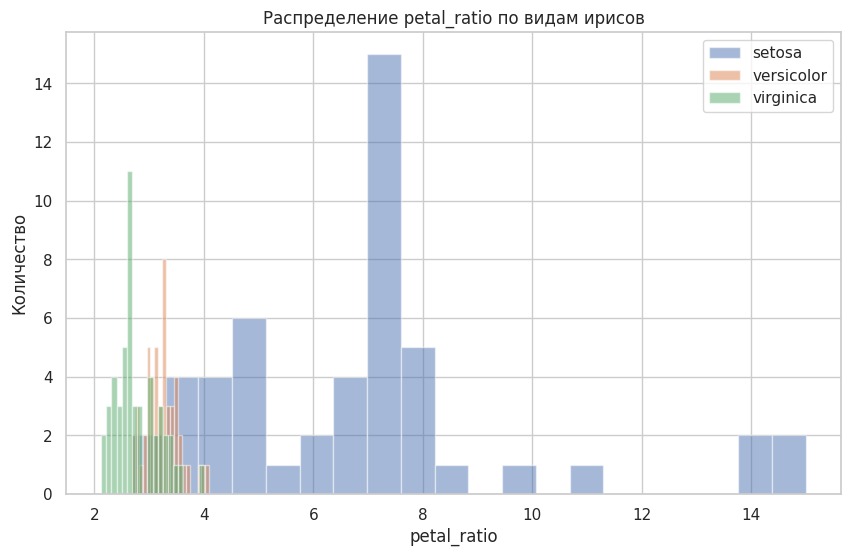

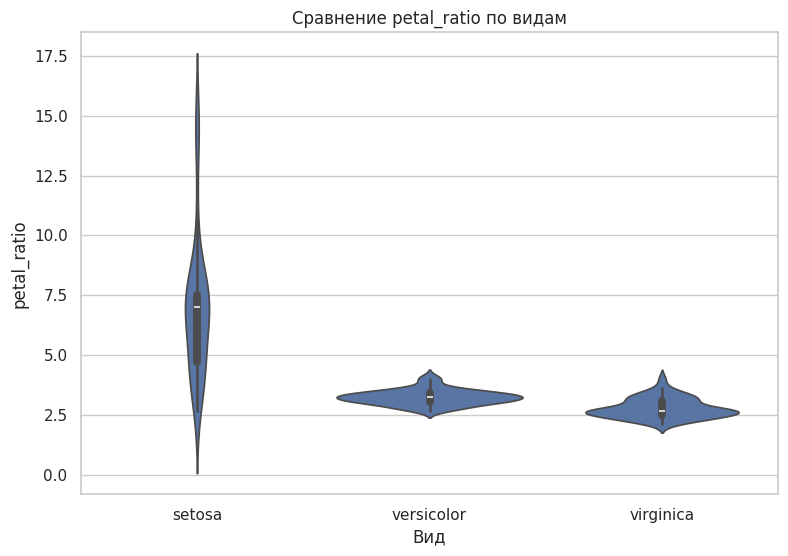

,mean,std,min,max
species,,,,
setosa,6.908,2.855,2.667,15.0
versicolor,3.243,0.312,2.667,4.1
virginica,2.781,0.407,2.125,4.0


In [4]:
df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']

display(df[['petal length (cm)', 'petal width (cm)', 'petal_ratio', 'species']].head())

plt.figure(figsize=(10, 6))
for name, part in df.groupby('species', observed=False):
    plt.hist(part['petal_ratio'], bins=20, alpha=0.5, label=str(name))
plt.legend()
plt.title('Распределение petal_ratio по видам ирисов')
plt.xlabel('petal_ratio')
plt.ylabel('Количество')
plt.show()

plt.figure(figsize=(9, 6))
sns.violinplot(data=df, x='species', y='petal_ratio')
plt.title('Сравнение petal_ratio по видам')
plt.xlabel('Вид')
plt.ylabel('petal_ratio')
plt.show()

display(df.groupby('species', observed=False)['petal_ratio'].agg(['mean', 'std', 'min', 'max']).round(3))

**Вывод:** новый признак хорошо отделяет *setosa*, но хуже разделяет *versicolor* и *virginica*, потому что их распределения по `petal_ratio` заметно пересекаются. По сравнению с исходными признаками лепестка он не даёт однозначного улучшения для всех классов.

## Практика 1.2. Wine

Подготовка данных.

In [5]:
from sklearn.datasets import load_wine
from scipy.stats import skew

wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target
wine_df['region'] = pd.Categorical.from_codes(wine.target, [f'Region_{i+1}' for i in range(3)])

print('Размер датасета:', wine_df.shape)
display(wine_df.head())
print('\nИнформация о данных:')
wine_df.info()
display(wine_df.iloc[:, :-2].describe().round(3))

Размер датасета: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,region
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Region_1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Region_1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Region_1
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Region_1
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Region_1



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   alcohol                       178 non-null    float64 
 1   malic_acid                    178 non-null    float64 
 2   ash                           178 non-null    float64 
 3   alcalinity_of_ash             178 non-null    float64 
 4   magnesium                     178 non-null    float64 
 5   total_phenols                 178 non-null    float64 
 6   flavanoids                    178 non-null    float64 
 7   nonflavanoid_phenols          178 non-null    float64 
 8   proanthocyanins               178 non-null    float64 
 9   color_intensity               178 non-null    float64 
 10  hue                           178 non-null    float64 
 11  od280/od315_of_diluted_wines  178 non-null    float64 
 12  proline                     

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


### Задание 1. Выявление мультиколлинеарности

Найти все пары признаков с абсолютной корреляцией |r| > 0.7, посчитать число таких пар и определить признак, чаще всего участвующий в сильных корреляциях.

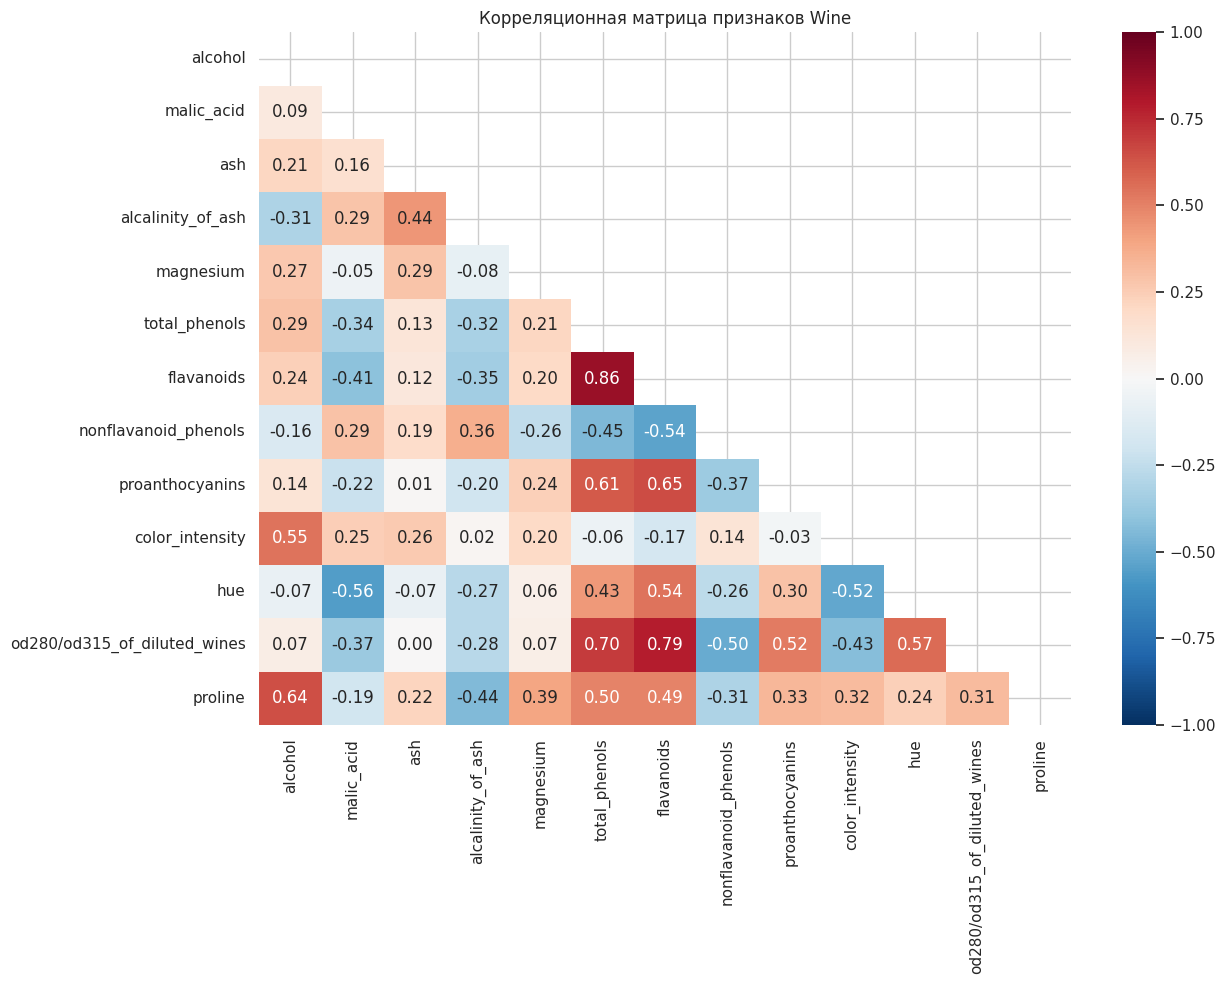

,Признак_1,Признак_2,Корреляция
0,total_phenols,flavanoids,0.865
1,flavanoids,od280/od315_of_diluted_wines,0.787


Количество пар с |r| > 0.7: 2


,Признак,Число сильных корреляций
0,flavanoids,2
1,total_phenols,1
2,od280/od315_of_diluted_wines,1


Чаще всего участвует в сильных корреляциях: flavanoids (2 раза)


In [6]:
wine_features = wine.feature_names
corr_matrix = wine_df[wine_features].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0)
plt.title('Корреляционная матрица признаков Wine')
plt.tight_layout()
plt.show()

pairs = []
for i in range(len(wine_features)):
    for j in range(i + 1, len(wine_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            pairs.append([wine_features[i], wine_features[j], r])

strong_corr = pd.DataFrame(pairs, columns=['Признак_1', 'Признак_2', 'Корреляция']).sort_values(by='Корреляция', key=lambda x: abs(x), ascending=False)
display(strong_corr.round(3))
print(f'Количество пар с |r| > 0.7: {len(strong_corr)}')

feature_counts = pd.concat([strong_corr['Признак_1'], strong_corr['Признак_2']]).value_counts()
display(feature_counts.rename_axis('Признак').reset_index(name='Число сильных корреляций'))
print(f'Чаще всего участвует в сильных корреляциях: {feature_counts.idxmax()} ({feature_counts.max()} раза)')

**Вывод:** в датасете есть несколько сильно коррелирующих пар признаков, что указывает на мультиколлинеарность. Наиболее часто в таких связях участвует `flavanoids`, поэтому при построении линейных моделей его связь с другими признаками нужно учитывать.

### Задание 2. Анализ асимметрии распределений

Рассчитать skewness для каждого признака и определить 3 признака с наибольшей положительной асимметрией.

,Признак,Асимметрия
0,magnesium,1.098
1,malic_acid,1.040
2,color_intensity,0.869
3,proline,0.768
4,proanthocyanins,0.517
5,nonflavanoid_phenols,0.450
6,alcalinity_of_ash,0.213
7,total_phenols,0.087
8,flavanoids,0.025
9,hue,0.021


Три признака с наибольшей положительной асимметрией:


,Признак,Асимметрия
0,magnesium,1.098
1,malic_acid,1.040
2,color_intensity,0.869


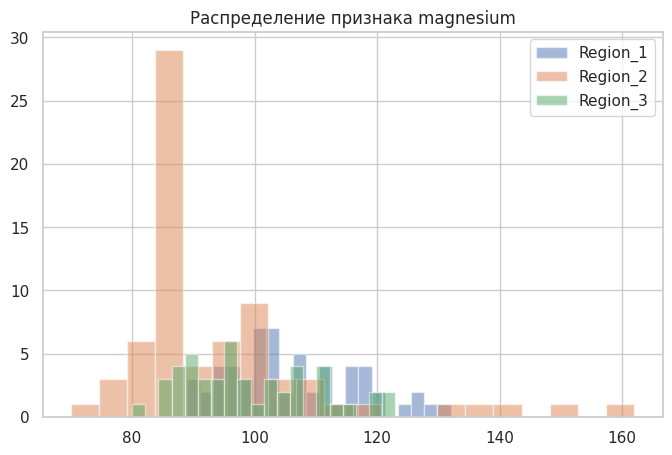

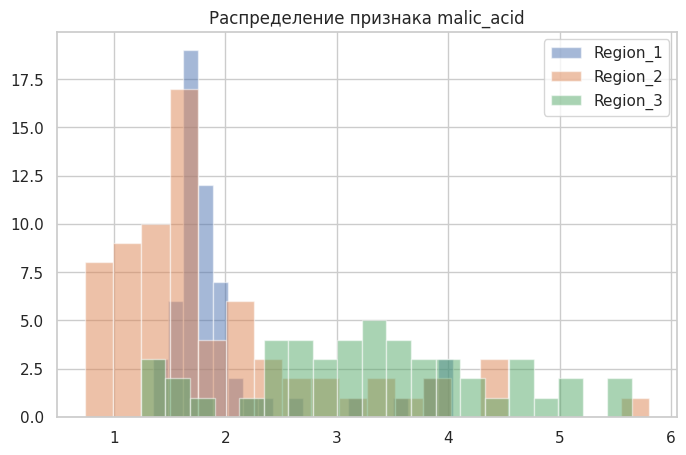

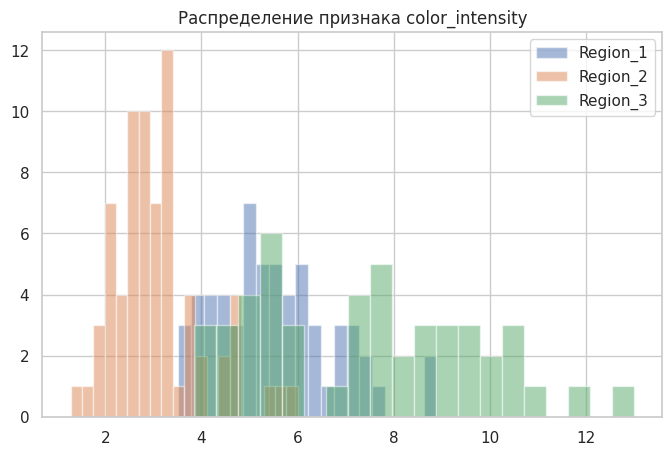

In [7]:
skew_values = pd.Series(skew(wine_df[wine_features], bias=False), index=wine_features).sort_values(ascending=False)
skew_table = skew_values.reset_index()
skew_table.columns = ['Признак', 'Асимметрия']
display(skew_table.round(3))

top3_skew = skew_table.head(3)
print('Три признака с наибольшей положительной асимметрией:')
display(top3_skew.round(3))

for feature in top3_skew['Признак']:
    plt.figure(figsize=(8, 5))
    for name, part in wine_df.groupby('region', observed=False):
        plt.hist(part[feature], bins=20, alpha=0.5, label=str(name))
    plt.legend()
    plt.title(f'Распределение признака {feature}')
    plt.show()

**Вывод:** признаки с сильной положительной асимметрией имеют длинный правый хвост. Для алгоритмов, чувствительных к масштабу и форме распределения, например SVM с RBF-ядром, такие признаки желательно масштабировать и при необходимости преобразовывать, например логарифмированием.

### Задание 3. Создание разделяющего признака

Создать `wine_quality_index = 0.6 * flavanoids + 0.4 * color_intensity`, построить распределение по регионам и сравнить разделимость с исходными признаками через коэффициент разделения классов.

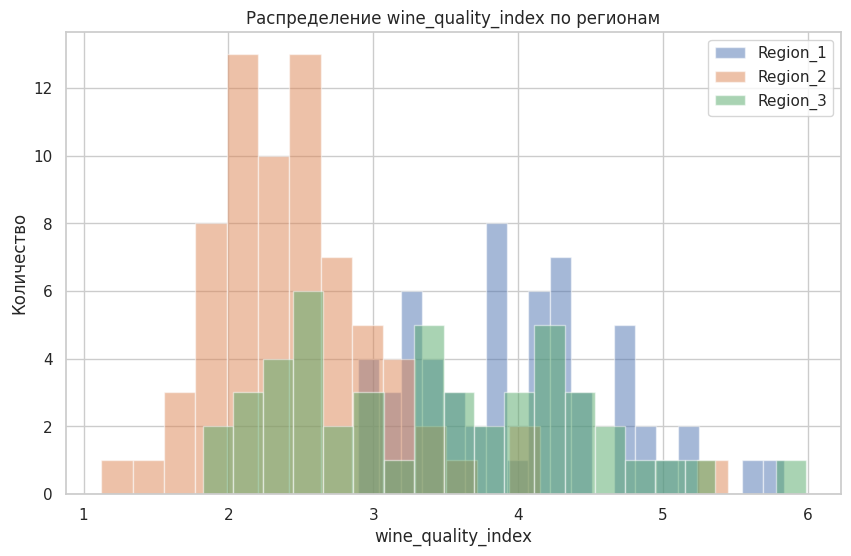

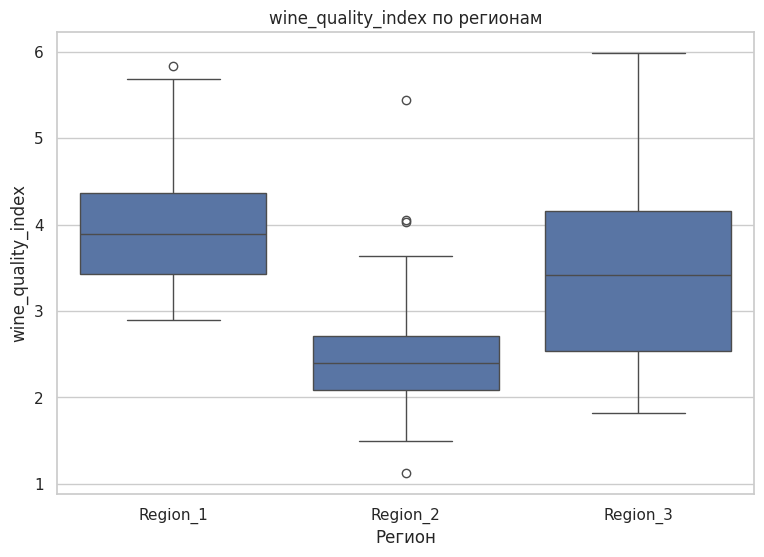

,Признак,Класс_1,Класс_2,Коэффициент_разделения
0,flavanoids,Region_1,Region_2,0.817
1,flavanoids,Region_1,Region_3,3.185
2,flavanoids,Region_2,Region_3,1.300
3,color_intensity,Region_1,Region_2,1.129
4,color_intensity,Region_1,Region_3,0.526
5,color_intensity,Region_2,Region_3,1.332
6,wine_quality_index,Region_1,Region_2,1.124
7,wine_quality_index,Region_1,Region_3,0.339
8,wine_quality_index,Region_2,Region_3,0.568


,Признак,Коэффициент_разделения
0,flavanoids,1.768
1,color_intensity,0.996
2,wine_quality_index,0.677


Лучшее среднее разделение даёт признак: flavanoids


In [8]:
wine_df['wine_quality_index'] = 0.6 * wine_df['flavanoids'] + 0.4 * wine_df['color_intensity']

plt.figure(figsize=(10, 6))
for name, part in wine_df.groupby('region', observed=False):
    plt.hist(part['wine_quality_index'], bins=20, alpha=0.5, label=str(name))
plt.legend()
plt.title('Распределение wine_quality_index по регионам')
plt.xlabel('wine_quality_index')
plt.ylabel('Количество')
plt.show()

plt.figure(figsize=(9, 6))
sns.boxplot(data=wine_df, x='region', y='wine_quality_index')
plt.title('wine_quality_index по регионам')
plt.xlabel('Регион')
plt.ylabel('wine_quality_index')
plt.show()

def pairwise_separation(data, feature, group_col='region'):
    groups = list(data[group_col].cat.categories)
    rows = []
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1, g2 = groups[i], groups[j]
            x1 = data.loc[data[group_col] == g1, feature]
            x2 = data.loc[data[group_col] == g2, feature]
            sep = abs(x1.mean() - x2.mean()) / (x1.std() + x2.std())
            rows.append([feature, g1, g2, sep])
    return pd.DataFrame(rows, columns=['Признак', 'Класс_1', 'Класс_2', 'Коэффициент_разделения'])

comparison = pd.concat([
    pairwise_separation(wine_df, 'flavanoids'),
    pairwise_separation(wine_df, 'color_intensity'),
    pairwise_separation(wine_df, 'wine_quality_index')
], ignore_index=True)

display(comparison.round(3))

summary_sep = comparison.groupby('Признак')['Коэффициент_разделения'].mean().sort_values(ascending=False)
display(summary_sep.reset_index().round(3))
print(f'Лучшее среднее разделение даёт признак: {summary_sep.idxmax()}')

**Вывод:** `wine_quality_index` объединяет информацию о флавоноидах и интенсивности цвета. По среднему коэффициенту разделения он сравнивается с исходными признаками количественно: если его среднее значение выше, значит комбинация улучшила разделение; если ниже — исходный признак разделяет регионы лучше. В данном датасете индекс полезен, но не обязательно превосходит лучший отдельный признак для всех пар классов.

## Итоговые выводы

1. В практике 1.1 выполнен анализ датасета Iris: проверены выбросы, рассчитаны коэффициенты вариации и создан новый признак `petal_ratio`. Наиболее изменчивым признаком оказался `petal width (cm)`.
3. В практике 1.2 выполнен анализ Wine: найдены сильно коррелирующие признаки, рассчитана асимметрия распределений и создан `wine_quality_index`. В Wine выражена мультиколлинеарность, а часть признаков имеет правостороннюю асимметрию, поэтому для дальнейшего машинного обучения потребуется масштабирование и, возможно, преобразование признаков.